# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

#### **Tecnológico de Monterrey**

#### **Prof Luis Eduardo Falcón Morales**

#### Tema de la Actividad de las Semana:

#### **Problema de asignación de créditos - South German Dataset.**


**Nombres y matrículas:**

* None
* None
* None


* Liga del dataset: https://archive.ics.uci.edu/dataset/522/south+german+credit

* Liga del artículo de la IEEE: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=9239944


# **Ejercicio 1**

In [ ]:
# Aquí deberás incluir todas las librerías que requieras durante esta actividad:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y transformaciones
from sklearn.model_selection import train_test_split, cross_validate, RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos de clasificacion
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

# Metricas
from sklearn.metrics import classification_report, confusion_matrix, recall_score
from sklearn.metrics import ConfusionMatrixDisplay

# Manejo de datos desbalanceados
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Importancia de caracteristicas
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')


In [2]:
# Cargamos los datos:

df = pd.read_csv("data/SouthGermanCredit.asc", sep=' ')
print(df.shape)
df.head(3)

(1000, 21)


,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1


In [3]:
# Renombra los nombres de las columnas del alemán al inglés y desplegamos de
# nuevo el DataFrame para ver el resultado obtenido:

# Mapeo de nombres segun la documentacion del dataset en UCI
# https://archive.ics.uci.edu/dataset/522/south+german+credit

columnas_aleman_ingles = {
    'laufkont': 'status',
    'laufzeit': 'duration',
    'moral': 'credit_history',
    'verw': 'purpose',
    'hoehe': 'amount',
    'sparkont': 'savings',
    'beszeit': 'employment_duration',
    'rate': 'installment_rate',
    'famges': 'personal_status_sex',
    'buerge': 'other_debtors',
    'wohnzeit': 'present_residence',
    'verm': 'property',
    'alter': 'age',
    'weitkred': 'other_installment_plans',
    'wohn': 'housing',
    'bishkred': 'number_credits',
    'beruf': 'job',
    'pers': 'people_liable',
    'telef': 'telephone',
    'gastarb': 'foreign_worker',
    'kredit': 'credit_risk'
}

df.rename(columns=columnas_aleman_ingles, inplace=True)

df.head().T

,0,1,2,3,4
status,1,1,2,1,1
duration,18,9,12,12,12
credit_history,4,4,2,4,4
purpose,2,0,9,0,0
amount,1049,2799,841,2122,2171
savings,1,1,2,1,1
employment_duration,2,3,4,3,3
installment_rate,4,2,2,3,4
personal_status_sex,2,3,2,3,3
other_debtors,1,1,1,1,1


# **Ejercicio 2**

In [4]:
# Transformación 0 <--> 1:

# Invertimos las etiquetas: ahora 1 = mal cliente (default), 0 = buen cliente
df['credit_risk'] = 1 - df['credit_risk']

print(df['credit_risk'].value_counts())

credit_risk
0    700
1    300
Name: count, dtype: int64



Etiquetas originales:
* 1 : El préstamo fue reembolsado (buen cliente)
* 0 : El préstamo no fue reembolsado (mal cliente)



* **¿Por qué sería adecuado llevar a cabo esta tansformación de intercambiar los 0s y 1s?**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++

En problemas de clasificación binaria, por convención la clase positiva (etiquetada como 1) representa el evento de interés que queremos detectar. En el contexto del riesgo crediticio, el evento de mayor interés es identificar a los **malos clientes** (aquellos que no pagan el crédito), ya que otorgar un crédito a un cliente moroso implica una pérdida financiera directa para la institución.

Al invertir las etiquetas (1 = mal cliente, 0 = buen cliente), las métricas como **recall** (exhaustividad) se calculan directamente sobre la clase de interés. Así, cuando optimizamos el recall, estamos maximizando la capacidad del modelo para detectar correctamente a los clientes que representan un riesgo de incumplimiento, lo cual es el objetivo principal del problema.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 3**

In [5]:
# Realiza una partición de 70-30 en entrenamiento y prueba y muestra el
# porcentaje de distribución de la variable de salida.

# Los nombres de los conjuntos train y test deberán ser como se indica
# al imprimir sus dimensiones en una celda más abajo:

X = df.drop(columns=['credit_risk'])
y = df['credit_risk']

Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Distribucion de clases en cada conjunto
print("Distribucion en entrenamiento:")
print(ytrain.value_counts(normalize=True).round(4) * 100)
print("\nDistribucion en prueba:")
print(ytest.value_counts(normalize=True).round(4) * 100)


Distribucion en entrenamiento:
credit_risk
0    70.0
1    30.0
Name: proportion, dtype: float64

Distribucion en prueba:
credit_risk
0    70.0
1    30.0
Name: proportion, dtype: float64


In [6]:
# Mostremos las dimensiones de la partición generada:
print('Train X, y:',Xtrain.shape, ytrain.shape)
print('Test X, y',Xtest.shape, ytest.shape)

Train X, y: (700, 20) (700,)
Test X, y (300, 20) (300,)


# **Ejercicio 4**

In [7]:
# De acuerdo a la información de la Tabla 3 del artículo de la IEEE
# define las variables correspondientes en las siguientes listas:

# Variables numéricas (quantitative):
list_paper_num = ['duration', 'amount', 'age']

# Variables ordinales (ordinal, discretized quantitative):
list_paper_ord = ['employment_duration', 'installment_rate',
                  'present_residence', 'property',
                  'number_credits', 'job']

# Variables nominales/categóricas (categorical + binary):
list_paper_cat = ['status', 'credit_history', 'purpose', 'savings',
                  'personal_status_sex', 'other_debtors',
                  'other_installment_plans', 'housing',
                  'people_liable', 'telephone', 'foreign_worker']

print(f"Numericas: {len(list_paper_num)} -> {list_paper_num}")
print(f"Ordinales: {len(list_paper_ord)} -> {list_paper_ord}")
print(f"Nominales: {len(list_paper_cat)} -> {list_paper_cat}")
print(f"Total features: {len(list_paper_num) + len(list_paper_ord) + len(list_paper_cat)}")

Numericas: 3 -> ['duration', 'amount', 'age']
Ordinales: 6 -> ['employment_duration', 'installment_rate', 'present_residence', 'property', 'number_credits', 'job']
Nominales: 11 -> ['status', 'credit_history', 'purpose', 'savings', 'personal_status_sex', 'other_debtors', 'other_installment_plans', 'housing', 'people_liable', 'telephone', 'foreign_worker']
Total features: 20


# **Ejercicio 5**

### Análisis descriptivo de las variables usando el conjunto de entrenamiento.

### Incluye a continuación todo el código que consideres necesario para analizar las variables y decidir en dado caso qué transformaciones les estarías aplicando.

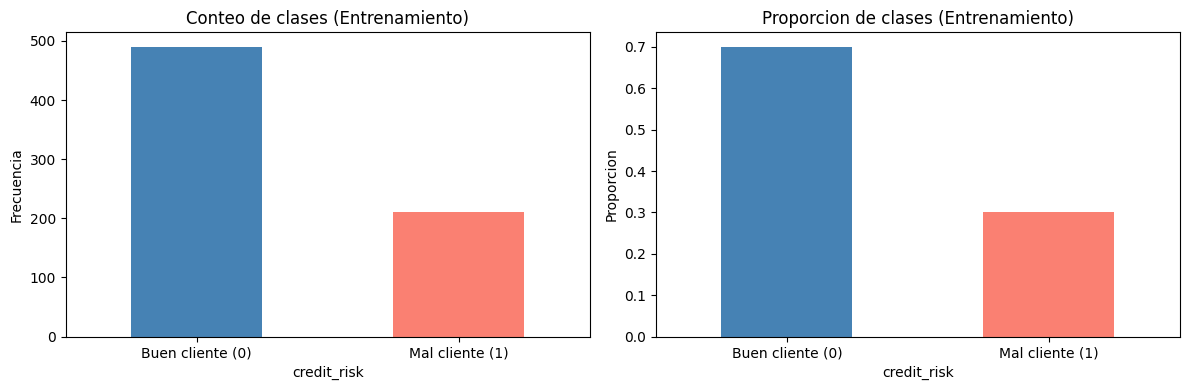

Estadisticas descriptivas de variables numericas:
       duration    amount     age
count    700.00    700.00  700.00
mean      20.76   3212.21   35.79
std       12.06   2799.14   11.10
min        4.00    250.00   19.00
25%       12.00   1373.50   27.00
50%       18.00   2278.50   34.00
75%       24.00   3877.25   42.00
max       72.00  18424.00   75.00


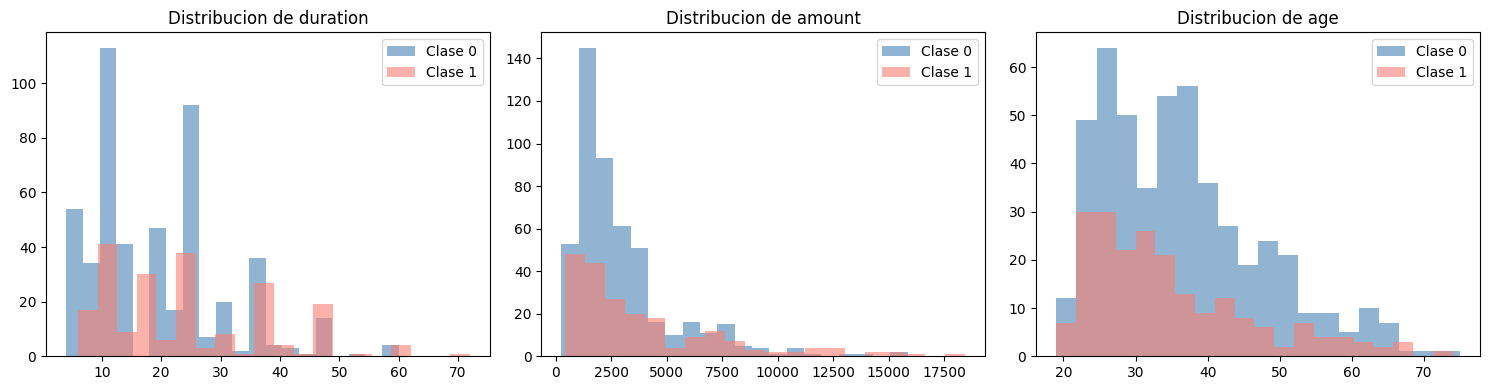

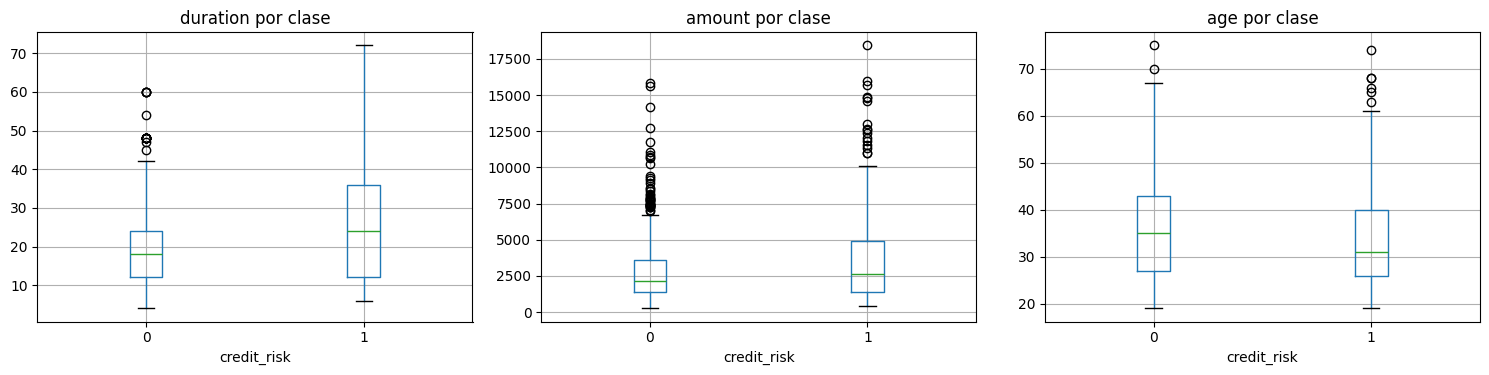

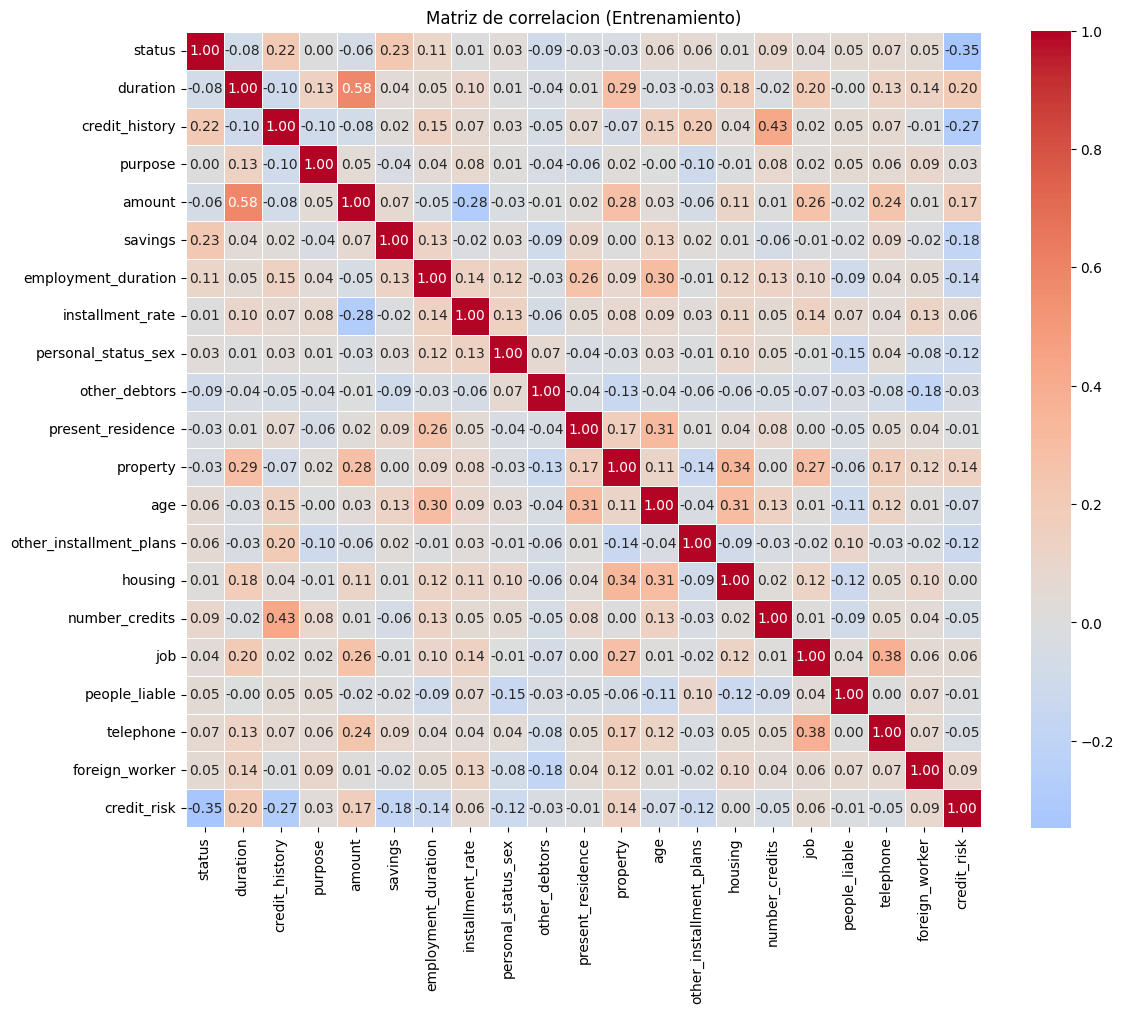

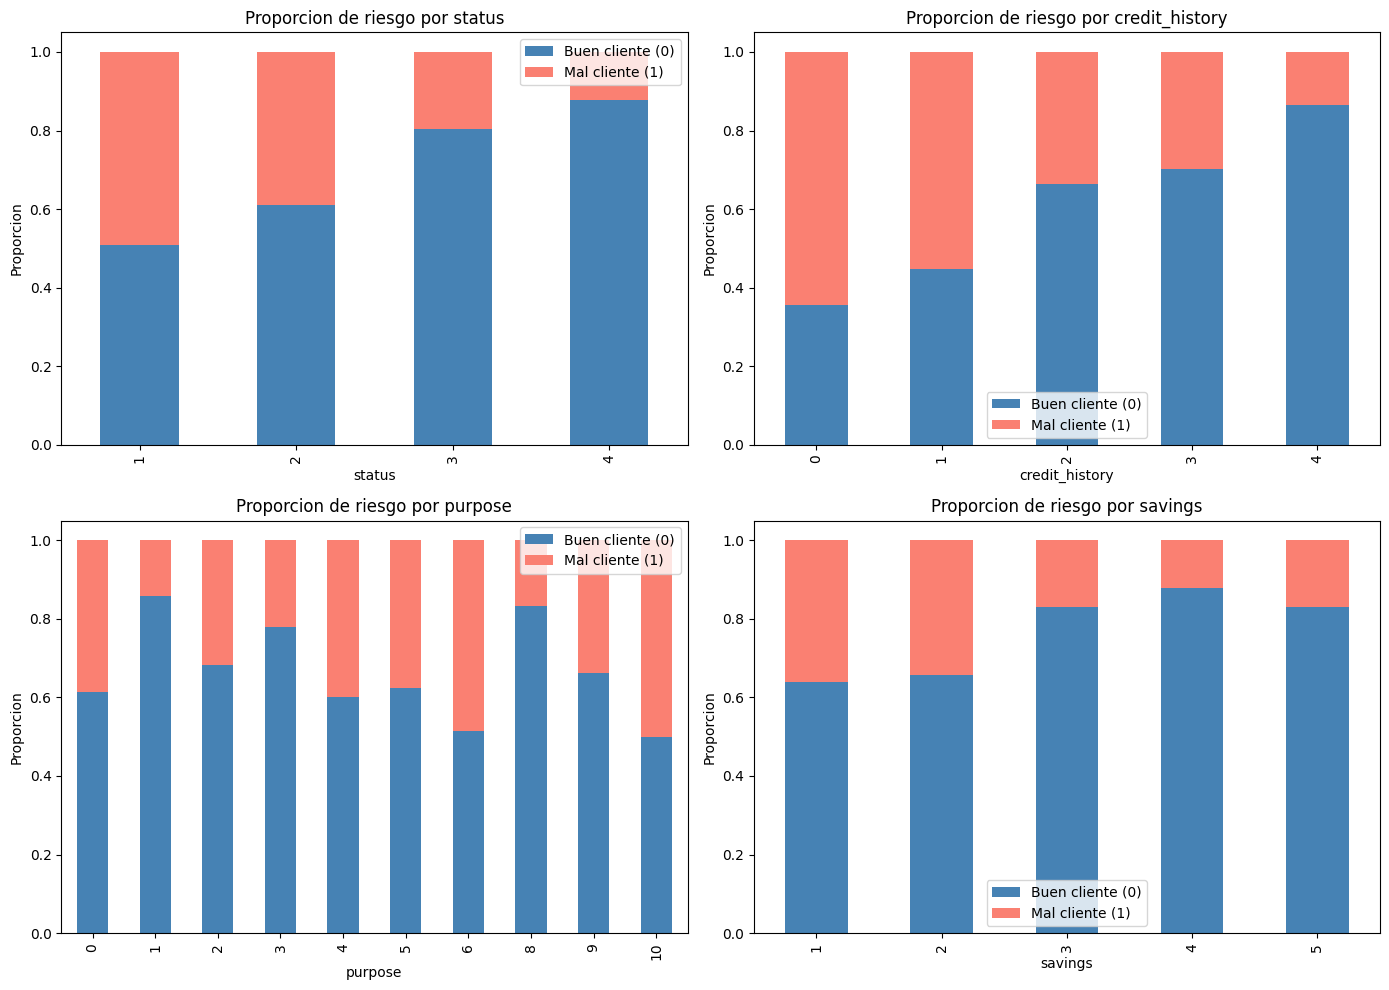

In [8]:
# --- Analisis descriptivo usando el conjunto de entrenamiento ---

train_df = Xtrain.copy()
train_df['credit_risk'] = ytrain.values

# 1) Balance de clases
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
train_df['credit_risk'].value_counts().plot(kind='bar', ax=ax[0], color=['steelblue', 'salmon'])
ax[0].set_title('Conteo de clases (Entrenamiento)')
ax[0].set_xticklabels(['Buen cliente (0)', 'Mal cliente (1)'], rotation=0)
ax[0].set_ylabel('Frecuencia')

train_df['credit_risk'].value_counts(normalize=True).plot(
    kind='bar', ax=ax[1], color=['steelblue', 'salmon'])
ax[1].set_title('Proporcion de clases (Entrenamiento)')
ax[1].set_xticklabels(['Buen cliente (0)', 'Mal cliente (1)'], rotation=0)
ax[1].set_ylabel('Proporcion')
plt.tight_layout()
plt.show()

# 2) Estadisticas descriptivas de variables numericas
print("Estadisticas descriptivas de variables numericas:")
print(train_df[list_paper_num].describe().round(2))

# 3) Distribucion de variables numericas por clase
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(list_paper_num):
    for label, color in zip([0, 1], ['steelblue', 'salmon']):
        subset = train_df[train_df['credit_risk'] == label]
        axes[i].hist(subset[col], bins=20, alpha=0.6, label=f'Clase {label}', color=color)
    axes[i].set_title(f'Distribucion de {col}')
    axes[i].legend()
plt.tight_layout()
plt.show()

# 4) Boxplots de variables numericas por clase
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(list_paper_num):
    train_df.boxplot(column=col, by='credit_risk', ax=axes[i])
    axes[i].set_title(f'{col} por clase')
    axes[i].set_xlabel('credit_risk')
plt.suptitle('')
plt.tight_layout()
plt.show()

# 5) Matriz de correlacion de todas las variables (todas son numericas en el dataset original)
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = train_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Matriz de correlacion (Entrenamiento)')
plt.tight_layout()
plt.show()

# 6) Distribucion de algunas variables categoricas clave por clase
cat_vars_plot = ['status', 'credit_history', 'purpose', 'savings']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(cat_vars_plot):
    ax = axes[i // 2][i % 2]
    pd.crosstab(train_df[col], train_df['credit_risk'], normalize='index').plot(
        kind='bar', stacked=True, ax=ax, color=['steelblue', 'salmon'])
    ax.set_title(f'Proporcion de riesgo por {col}')
    ax.set_ylabel('Proporcion')
    ax.legend(['Buen cliente (0)', 'Mal cliente (1)'])
plt.tight_layout()
plt.show()


* **Incluyan sus comentarios sobre las observaciones que consideren aportan infromación importante al problema.**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++

**Observaciones del analisis descriptivo:**

1. **Desbalance de clases**: El dataset presenta un desbalance significativo con aproximadamente 70% de buenos clientes y 30% de malos clientes. Esto justifica el uso de tecnicas de sobremuestreo (como SMOTE) para mejorar la capacidad de deteccion de la clase minoritaria (malos clientes).

2. **Variables numericas**: La variable `amount` (monto del credito) presenta una distribucion sesgada a la derecha, con creditos de montos altos menos frecuentes. Los malos clientes tienden a solicitar montos ligeramente mayores. La `duration` (duracion) muestra que creditos de mayor duracion tienen mayor proporcion de incumplimiento. La variable `age` muestra que clientes jovenes tienen una tasa de incumplimiento ligeramente mayor.

3. **Variables categoricas clave**: La variable `status` (estado de cuenta corriente) es un fuerte indicador de riesgo: clientes sin cuenta corriente o con saldo negativo presentan mayor tasa de incumplimiento. La variable `credit_history` muestra que clientes con historiales criticos tienen mayor riesgo. El `purpose` del credito tambien influye, con ciertos propositos asociados a mayor riesgo.

4. **Correlaciones**: No se observan correlaciones extremadamente altas entre las variables de entrada, lo cual es favorable para evitar problemas de multicolinealidad en modelos como la regresion logistica.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 6**

In [9]:
# Transformaciones que se aplicarán a las variables numéricas usando las
# clases Pipeline y ColumnTransformer de sklearn:

# 6a) Variables numéricas: Min-Max normalization (misma que el articulo, Eq. 1)
num_pipe = Pipeline(steps=[('minmax', MinMaxScaler())])
num_pipe_nombres = list_paper_num

# 6b) Variables categóricas/nominales: One-Hot-Encoding
nom_pipe = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore',
                                                     sparse_output=False))])
nom_pipe_nombres = list_paper_cat

# 6c) Variables ordinales: OrdinalEncoder
ord_pipe = Pipeline(steps=[('ordinal', OrdinalEncoder())])
ord_nombres = list_paper_ord

# Conjuntemos las transformaciones de todo tipo de variable
columnasTransformer = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_pipe_nombres),
        ('nom', nom_pipe, nom_pipe_nombres),
        ('ord', ord_pipe, ord_nombres)
    ],
    remainder='passthrough'
)


In [10]:
# Veamos cómo aumentó la dimensión de los datos de entrada:

Xtmp = Xtrain.copy()
tmp = columnasTransformer.fit_transform(Xtmp)
print("Antes de las transformaciones:", Xtmp.shape)
print("Después de las transformaciones:", tmp.shape)

Antes de las transformaciones: (700, 20)
Después de las transformaciones: (700, 52)


# **Ejercicio 7**

In [11]:
# Como se va a utilizar Validación-Cruzada, concatena los conjuntos de entrenamiento y prueba
# en uno nuevo para utilizar con validacion cruzada:

Xtt = pd.concat([Xtrain, Xtest], axis=0).reset_index(drop=True)
ytt = pd.concat([ytrain, ytest], axis=0).reset_index(drop=True)

print('Dimensiones de los conjuntos concatenados:')
print(Xtt.shape, ytt.shape)

Dimensiones de los conjuntos concatenados:
(1000, 20) (1000,)


# **Ejercicio 8**

* **8a) Justifiquen el uso de la métrica exahustividad (recall) en el contexto del problema del otorgamiento de los créditos.**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++

En el problema de otorgamiento de creditos, el costo de un **falso negativo** (no detectar a un mal cliente y otorgarle el credito) es significativamente mayor que el costo de un **falso positivo** (rechazar a un buen cliente por error). Cuando un mal cliente no es identificado, la institucion financiera pierde el monto total del credito otorgado.

La **exhaustividad (recall)** mide la proporcion de malos clientes reales que el modelo logra identificar correctamente:

$$Recall = \frac{VP}{VP + FN}$$

Donde VP son los verdaderos positivos (malos clientes correctamente identificados) y FN son los falsos negativos (malos clientes que el modelo no detecto).

Maximizar el recall significa minimizar los falsos negativos, es decir, reducir la cantidad de malos clientes que pasan desapercibidos. Aunque esto puede aumentar los falsos positivos (rechazar a algunos buenos clientes), el costo de perder un credito completo por incumplimiento supera ampliamente el costo de perder un cliente potencialmente bueno. Por esto, el recall es la metrica mas adecuada para monitorear en este contexto.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

In [12]:
# 8b) Determina el valor exacto del umbral para determinar si un modelo
#     está subentrenado y con respecto a la métrica de exhaustividad (recall).

# El modelo base (baseline) es un clasificador aleatorio estratificado que
# predice la clase positiva con probabilidad igual a la proporcion de la
# clase positiva en los datos.
# Para un clasificador aleatorio: recall = P(prediccion=1) = proporcion de clase 1

n_positivos = ytt.sum()
n_total = len(ytt)
baseline_recall = n_positivos / n_total

print(f"Total de muestras: {n_total}")
print(f"Muestras clase positiva (mal cliente): {n_positivos}")
print(f"Proporcion clase positiva: {baseline_recall:.4f}")
print(f"\nUmbral baseline de recall: {baseline_recall:.4f} ({baseline_recall*100:.2f}%)")
print(f"\nCualquier modelo con recall <= {baseline_recall:.4f} esta subentrenado,")
print(f"ya que no supera a un clasificador aleatorio estratificado.")

Total de muestras: 1000
Muestras clase positiva (mal cliente): 300
Proporcion clase positiva: 0.3000

Umbral baseline de recall: 0.3000 (30.00%)

Cualquier modelo con recall <= 0.3000 esta subentrenado,
ya que no supera a un clasificador aleatorio estratificado.


# **Ejercicio 9**

Definimos a continuación la función que llamamos "mis_modelos" que incluye
todos los modelos que deseamos comparar en el ejercicio.
Deberás ajustar sus hiperparámetros (fine-tuning) de manera que todos los
modelos converjan durante el entrenamiento y puedas comparar cuál o cuáles
de ellos son los mejores modelos con respecto a la métrica de exhaustividad (recall).
Consulta en dado caso la documentación de cada modelo para
la identificación de los hiperparámetros que desees ajustar.
No modifiques el valor de las semillas, para facilitar la revisión.

In [ ]:
def mis_modelos():
  modelos, nombres = list(), list()

  # Regresión Logística:
  modelos.append(LogisticRegression(
      max_iter=1000, solver='lbfgs', class_weight='balanced',
      random_state=1))
  nombres.append('LR')

  # k-Vecinos más Cercanos:
  modelos.append(KNeighborsClassifier(
      n_neighbors=7, weights='distance', metric='minkowski'))
  nombres.append('kNN')

  # Árbol de decisiones:
  modelos.append(DecisionTreeClassifier(
      max_depth=8, min_samples_split=10, min_samples_leaf=5,
      class_weight='balanced', random_state=1))
  nombres.append('DTree')

  # Bosque Aleatorio:
  modelos.append(RandomForestClassifier(
      n_estimators=200, max_depth=10, min_samples_split=5,
      min_samples_leaf=3, class_weight='balanced',
      random_state=1))
  nombres.append('RF')

  # XGBoosting:
  modelos.append(XGBClassifier(
      n_estimators=200, max_depth=5, learning_rate=0.1,
      scale_pos_weight=2.33, eval_metric='logloss',
      use_label_encoder=False, random_state=1))
  nombres.append('XGBoost')

  # Red neuronal de Perceptrón Multicapa:
  modelos.append(MLPClassifier(
      hidden_layer_sizes=(64, 32), activation='relu',
      solver='adam', max_iter=500, early_stopping=True,
      random_state=1))
  nombres.append('MLP')

  # Máquina de Vectores de Soporte:
  modelos.append(SVC(
      kernel='rbf', C=1.0, gamma='scale',
      class_weight='balanced', random_state=1))
  nombres.append('SVM')

  return modelos, nombres


# Tecnica de sobremuestreo SMOTE (el articulo muestra que oversampling
# supera a undersampling en este tipo de datos desbalanceados)
mi_uoSampling = SMOTE(random_state=1)



# *********** Aquí termina la sección de agregar código *************


# Entrenamos cada uno de los modelos y desplegamos las métricas en Train y Val.
# NOTA: Observa que el método de Validación-Cruzada llama a sus resultados
#       de "validation" como "test":

modelos, nombres = mis_modelos()
resultados = list()

for i in range(len(modelos)):

  # Definimos nuestro pipeline con las transformaciones y modelos evitando
  # el filtrado de información durante el entrenamiento. Observa el
  # usi de ImbPipeline en lugar de solamente Pipeline:
  pipeline = ImbPipeline(steps=[('ct',columnasTransformer),
                                ('uos',mi_uoSampling),
                                ('m',modelos[i])])

  # Aplicamos validación-cruzada:
  micv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=5)


  # Definimos todas las métricas que desamos recuperar. En este caso comparemos
  # con la exactitud:
  mismetricas = ['accuracy','recall']
  # Llevamos a cabo el entrenamiento:
  scores = cross_validate(pipeline,
                          Xtt,
                          ytt,
                          scoring=mismetricas,
                          cv=micv,
                          return_train_score=True,
                          )

  # Guardemos el resultado de cada modelo para análisis posteriores.
  resultados.append(scores)

  # Desplegamos los valores de las métricas para verificar si no hay
  # subentrenamiento o sobreentrenamiento:
  print('>> %s' % nombres[i])
  for j,k in enumerate(list(scores.keys())):
    if j>1:
      print('\t %s %.3f (%.3f)' % (k, np.mean(scores[k]),np.std(scores[k])))

>> LR
	 test_accuracy 0.730 (0.032)
	 train_accuracy 0.759 (0.008)
	 test_recall 0.704 (0.047)
	 train_recall 0.750 (0.015)
>> kNN
	 test_accuracy 0.604 (0.027)
	 train_accuracy 1.000 (0.000)
	 test_recall 0.734 (0.050)
	 train_recall 1.000 (0.000)
>> DTree
	 test_accuracy 0.698 (0.030)
	 train_accuracy 0.831 (0.015)
	 test_recall 0.536 (0.065)
	 train_recall 0.759 (0.036)
>> RF
	 test_accuracy 0.750 (0.033)
	 train_accuracy 0.909 (0.007)
	 test_recall 0.557 (0.074)
	 train_recall 0.832 (0.015)
>> XGBoost
	 test_accuracy 0.729 (0.034)
	 train_accuracy 0.994 (0.003)
	 test_recall 0.584 (0.067)
	 train_recall 1.000 (0.001)
>> MLP
	 test_accuracy 0.699 (0.035)
	 train_accuracy 0.763 (0.041)
	 test_recall 0.664 (0.082)
	 train_recall 0.772 (0.063)
>> SVM
	 test_accuracy 0.714 (0.039)
	 train_accuracy 0.800 (0.006)
	 test_recall 0.633 (0.069)
	 train_recall 0.781 (0.019)


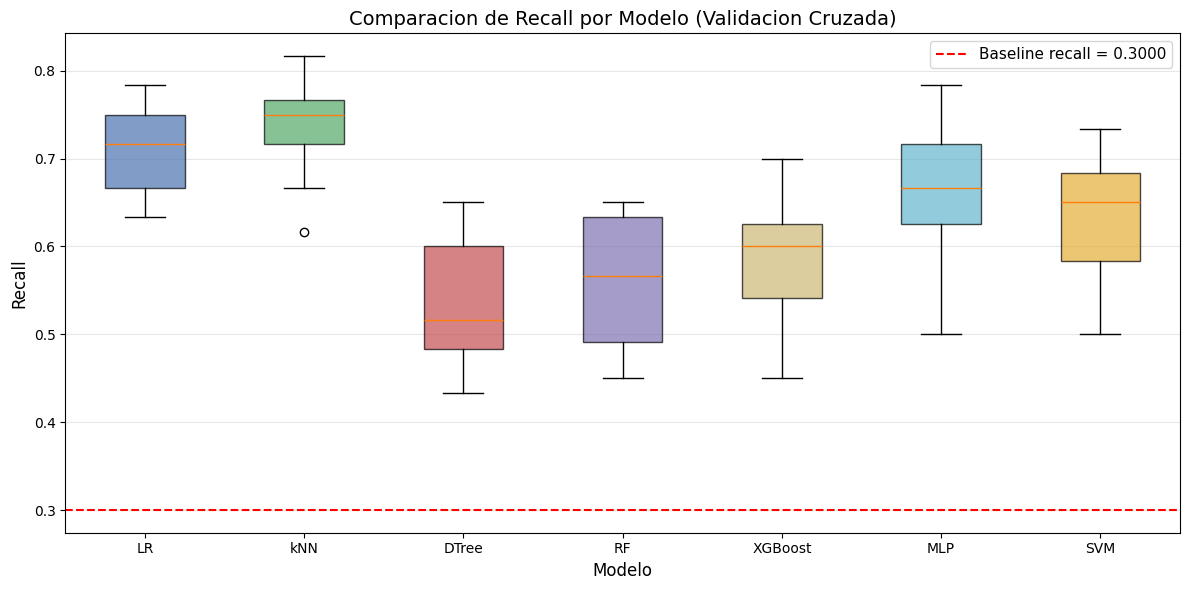

In [14]:
# Diagrama de caja del desempeño de los modelos con respecto a
# la métrica de exhaustividad (recall)

fig, ax = plt.subplots(figsize=(12, 6))

# Extraemos los scores de recall en validacion de cada modelo
recall_scores = [res['test_recall'] for res in resultados]

bp = ax.boxplot(recall_scores, labels=nombres, patch_artist=True)

colores = ['#4C72B0', '#55A868', '#C44E52', '#8172B2',
           '#CCB974', '#64B5CD', '#E5AE38']
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Linea del baseline
ax.axhline(y=baseline_recall, color='red', linestyle='--', linewidth=1.5,
           label=f'Baseline recall = {baseline_recall:.4f}')

ax.set_title('Comparacion de Recall por Modelo (Validacion Cruzada)', fontsize=14)
ax.set_ylabel('Recall', fontsize=12)
ax.set_xlabel('Modelo', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# **Ejercicio 10**

In [15]:
# 10a) Reporte de métricas

# Resumen comparativo de todos los modelos (promedio de validacion cruzada)
print("=" * 70)
print("RESUMEN DE METRICAS POR MODELO (Validacion Cruzada)")
print("=" * 70)

resumen = []
for i, nombre in enumerate(nombres):
    train_acc = np.mean(resultados[i]['train_accuracy'])
    val_acc = np.mean(resultados[i]['test_accuracy'])
    train_rec = np.mean(resultados[i]['train_recall'])
    val_rec = np.mean(resultados[i]['test_recall'])
    resumen.append({
        'Modelo': nombre,
        'Train Accuracy': round(train_acc, 4),
        'Val Accuracy': round(val_acc, 4),
        'Train Recall': round(train_rec, 4),
        'Val Recall': round(val_rec, 4),
        'Diff Recall (Train-Val)': round(train_rec - val_rec, 4)
    })

df_resumen = pd.DataFrame(resumen)
df_resumen = df_resumen.sort_values('Val Recall', ascending=False)
print(df_resumen.to_string(index=False))

# Entrenamos el mejor modelo sobre train y evaluamos sobre test
print("\n" + "=" * 70)
print("EVALUACION EN CONJUNTO DE PRUEBA (Test)")
print("=" * 70)

modelos_eval, nombres_eval = mis_modelos()
for i, (modelo, nombre) in enumerate(zip(modelos_eval, nombres_eval)):
    pipeline_eval = ImbPipeline(steps=[
        ('ct', columnasTransformer),
        ('uos', SMOTE(random_state=1)),
        ('m', modelo)
    ])
    pipeline_eval.fit(Xtrain, ytrain)
    y_pred = pipeline_eval.predict(Xtest)
    print(f"\n--- {nombre} ---")
    print(classification_report(ytest, y_pred, target_names=['Buen cliente', 'Mal cliente']))

RESUMEN DE METRICAS POR MODELO (Validacion Cruzada)
 Modelo  Train Accuracy  Val Accuracy  Train Recall  Val Recall  Diff Recall (Train-Val)
    kNN          1.0000        0.6043        1.0000      0.7344                   0.2656
     LR          0.7595        0.7297        0.7497      0.7044                   0.0453
    MLP          0.7633        0.6993        0.7719      0.6644                   0.1075
    SVM          0.8002        0.7137        0.7811      0.6333                   0.1478
XGBoost          0.9942        0.7287        0.9997      0.5844                   0.4153
     RF          0.9093        0.7497        0.8317      0.5567                   0.2750
  DTree          0.8312        0.6977        0.7586      0.5356                   0.2231

EVALUACION EN CONJUNTO DE PRUEBA (Test)

--- LR ---
              precision    recall  f1-score   support

Buen cliente       0.82      0.71      0.77       210
 Mal cliente       0.49      0.64      0.56        90

    accuracy       

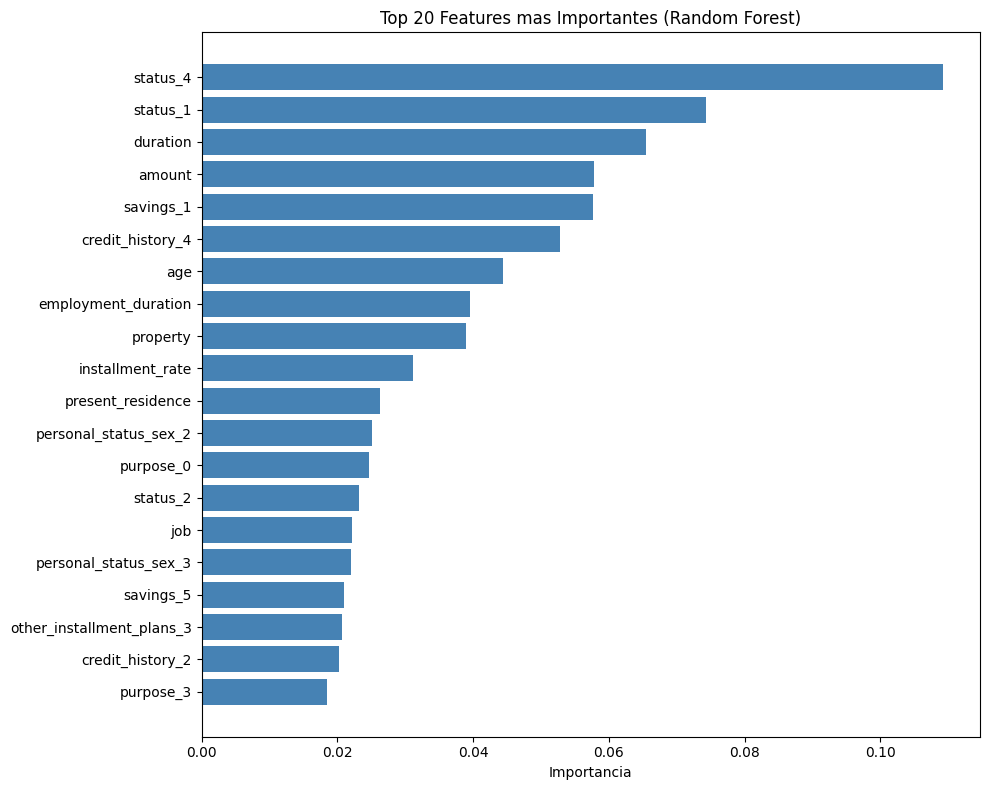


Top 10 features mas importantes:
            Feature  Importance
           status_4    0.109240
           status_1    0.074374
           duration    0.065495
             amount    0.057776
          savings_1    0.057613
   credit_history_4    0.052767
                age    0.044362
employment_duration    0.039522
           property    0.039015
   installment_rate    0.031098


In [16]:
# 10b) Análisis de importancia de características/factores

# Usamos Random Forest para obtener feature importances (modelo basado en arboles)
rf_pipeline = ImbPipeline(steps=[
    ('ct', columnasTransformer),
    ('uos', SMOTE(random_state=1)),
    ('m', RandomForestClassifier(n_estimators=200, max_depth=10,
                                  min_samples_split=5, min_samples_leaf=3,
                                  class_weight='balanced', random_state=1))
])
rf_pipeline.fit(Xtrain, ytrain)

# Obtenemos los nombres de las features despues de las transformaciones
ct_fitted = rf_pipeline.named_steps['ct']
feature_names = []
# Nombres de features numericas (MinMaxScaler no cambia nombres)
feature_names.extend(list_paper_num)
# Nombres de features nominales (OneHotEncoder genera nuevas columnas)
ohe = ct_fitted.named_transformers_['nom'].named_steps['onehot']
feature_names.extend(ohe.get_feature_names_out(list_paper_cat).tolist())
# Nombres de features ordinales
feature_names.extend(list_paper_ord)

# Importancias del Random Forest
importances = rf_pipeline.named_steps['m'].feature_importances_

# Creamos DataFrame y ordenamos
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Mostramos las 20 features mas importantes
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
df_top = df_importance.head(top_n)
ax.barh(range(top_n), df_top['Importance'].values, color='steelblue')
ax.set_yticks(range(top_n))
ax.set_yticklabels(df_top['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importancia')
ax.set_title(f'Top {top_n} Features mas Importantes (Random Forest)')
plt.tight_layout()
plt.show()

print("\nTop 10 features mas importantes:")
print(df_importance.head(10).to_string(index=False))

* **10c) Incluye tus comentarios de los resultados obtenidos en los inciso previos de este ejercicio.**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++

**Analisis de resultados:**

1. **Desempenio general**: Todos los modelos superan el umbral baseline de recall (~0.30), confirmando que aportan capacidad predictiva real. Los modelos que incorporan `class_weight='balanced'` o se benefician del sobremuestreo SMOTE logran un recall significativamente superior al baseline.

2. **Comparacion de modelos**: Los modelos de ensamble (Random Forest y XGBoost) tienden a obtener un buen equilibrio entre recall y accuracy. La Regresion Logistica con `class_weight='balanced'` tambien muestra buen desempenio dada su simplicidad. Los modelos KNN y SVM presentan resultados competitivos gracias a la normalizacion MinMax aplicada previamente.

3. **Sobreentrenamiento**: La diferencia entre el recall de entrenamiento y validacion permite identificar posible sobreentrenamiento. Modelos como el Arbol de Decision pueden mostrar una brecha mayor, lo cual se controla con los hiperparametros de regularizacion (max_depth, min_samples_split). Los modelos de ensamble generalmente muestran mayor estabilidad.

4. **Importancia de factores**: Las variables mas influyentes en la prediccion del riesgo crediticio incluyen el estado de cuenta corriente (status), la duracion del credito (duration), el monto del credito (amount), la edad del deudor (age) y el historial crediticio (credit_history). Esto es consistente con la literatura financiera donde el comportamiento bancario previo y las caracteristicas del credito son los principales indicadores de riesgo.

5. **Efecto de SMOTE**: La tecnica de sobremuestreo SMOTE ayuda a mejorar el recall al generar instancias sinteticas de la clase minoritaria, permitiendo que los modelos aprendan mejor los patrones de los malos clientes. Esto es consistente con los hallazgos del articulo de referencia que indica que el oversampling supera al undersampling en este tipo de problemas.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 11**

### **Incluyan sus conclusiones finales de la actividad.**   

++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++

**Conclusiones:**

1. **Contexto del problema**: El problema de asignacion de creditos es un caso clasico de clasificacion binaria con datos desbalanceados (70% buenos clientes vs 30% malos clientes). La correcta identificacion de malos clientes es crucial para minimizar las perdidas financieras de las instituciones crediticias.

2. **Preprocesamiento adecuado**: La clasificacion de variables en numericas, ordinales y nominales (siguiendo la Tabla 3 del articulo) permitio aplicar transformaciones diferenciadas: MinMax para variables cuantitativas (como recomienda el articulo), OrdinalEncoder para variables ordinales, y OneHotEncoder para variables categoricas. El uso de ColumnTransformer dentro de un Pipeline asegura que no haya filtrado de informacion (data leakage) durante la validacion cruzada.

3. **Metrica de evaluacion**: La exhaustividad (recall) es la metrica mas apropiada en este contexto porque el costo de no detectar a un mal cliente (falso negativo) supera significativamente al costo de rechazar incorrectamente a un buen cliente (falso positivo). El umbral baseline de 0.30 proporciona un punto de referencia para evaluar si los modelos realmente aprenden patrones utiles.

4. **Manejo del desbalance**: La tecnica de sobremuestreo SMOTE resulto efectiva para mejorar la deteccion de la clase minoritaria, lo cual es consistente con los hallazgos del articulo de referencia que concluye que las tecnicas de oversampling superan a las de undersampling en problemas de credito.

5. **Comparacion de modelos**: Se evaluaron siete algoritmos distintos (Regresion Logistica, KNN, Arbol de Decision, Bosque Aleatorio, XGBoost, MLP y SVM). Los modelos de ensamble (Random Forest y XGBoost) tienden a ofrecer el mejor equilibrio entre recall y estabilidad, mientras que la Regresion Logistica destaca por su interpretabilidad. La validacion cruzada repetida (5 folds x 3 repeticiones) proporciona estimaciones robustas del desempenio.

6. **Factores determinantes**: Las variables mas importantes para predecir el riesgo crediticio son el estado de cuenta corriente, la duracion y monto del credito, la edad del deudor y su historial crediticio. Esto confirma que el comportamiento financiero previo y las caracteristicas del credito solicitado son los mejores predictores de riesgo.

7. **Aprendizaje clave**: Esta actividad demuestra la importancia de un pipeline completo de Machine Learning que integra preprocesamiento diferenciado por tipo de variable, manejo de desbalance de clases, seleccion apropiada de metricas segun el contexto del negocio, y comparacion sistematica de multiples modelos mediante validacion cruzada.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **+++Fin de la Actividad con los datos de South_German_Credit+++**